In [1]:
from models import InitializationAngle
from utils import GraspAnalysisUtils
from pathlib import Path
import numpy as np

In [2]:
# Find folder containing CSV files for analysis
data_file = GraspAnalysisUtils.select_file()

Selected file: C:/Users/rjs15/grasp_strength_ws/astm_grasp_strength_analysis/sample_data/robotiq_intialization/RobotIQ_70SFMA_33Cycles_DeterminePositionMaxGraspStrength.csv


In [3]:
# Get initialization variables
starting_angle, increment, trials = GraspAnalysisUtils.get_initialization_parameters()

User has chosen a starting angle of -25.0 degrees

User has chosen an angle increment of 5.0 degrees

User has specified 3 per angle increment


In [5]:
# Assignment of variables
SAMPLE_SIZE = 200
OFFSET = 2000
MIN_FORCE_THRESHOLD = 10

10773
10828
10782
10781
10826
10819
10827
10837
10901
10977
11070
11024
11055
11065
11040
11010
11017
11021
11050
11137
11098
11076
10984
11080
11010
10927
11057
11016
11137
11038
11014
11072
10984
Filename: RobotIQ_70SFMA_33Cycles_DeterminePositionMaxGraspStrength.csv
Optimal angle: 5.0 degrees
Force at optimal angle: 177.6883229197647 N
Number of grasps analyzed: 33


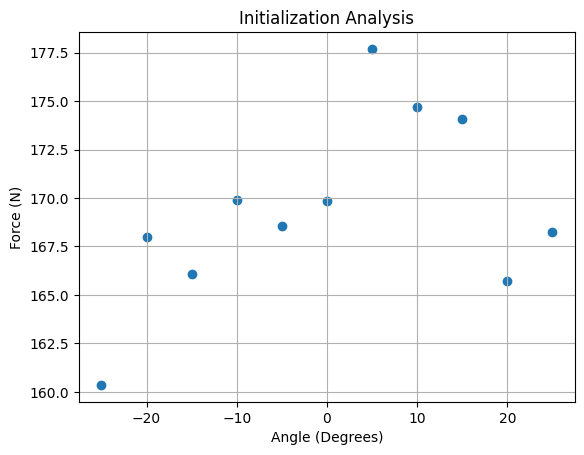

In [6]:
filename = Path(data_file).name

force_data = GraspAnalysisUtils.load_and_preprocess_data(data_file)

grasps = GraspAnalysisUtils.detect_grasp_regions(force_data, SAMPLE_SIZE, MIN_FORCE_THRESHOLD)
number_of_grasps = len(grasps)

if number_of_grasps == 0:
    Warning(f"No grasps detected in file: {filename}")

rolling_avg = []
rolling_std = []
rolling_median = []

avg_forces = []
for grasp in grasps:
    grasp = GraspAnalysisUtils.calculate_grasp_force(force_data[grasp.start_idx:grasp.end_idx], grasp, OFFSET)

    avg_forces.append(grasp.avg_force)
    rolling_avg.append(np.mean(avg_forces))
    rolling_std.append(np.std(avg_forces))
    rolling_median.append(np.median(avg_forces))

max_force, max_angle = GraspAnalysisUtils.analyze_initialization_angles(avg_forces, starting_angle, increment, trials)

GraspAnalysisUtils.report_initialization_results(filename, number_of_grasps, max_force, max_angle)